In [1]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import GPy
from scipy.special import expit
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.spatial import distance
import statsmodels.api as sm
import warnings
import numpy as np
from scipy.optimize import differential_evolution
from scipy.stats import rankdata
from sklearn.cross_decomposition import CCA
import math
import copy
from math import log
from collections import Counter
import pickle
from sklearn.linear_model import Lasso
warnings.filterwarnings("ignore")

In [2]:
# Read beta back from the file
beta_star = np.load('beta_star.npy')
print("beta_star:", beta_star)
n_features = len(beta_star)

np.sum(beta_star[beta_star > 0])

beta_star: [ 0.          0.          0.          0.          0.          0.
  0.          0.         -9.35929044 -8.23056672  0.          0.
  0.          0.          0.          0.          0.         -1.93149689
  0.          0.          0.          0.          0.          0.
  0.          0.         -4.01959343  0.          4.46057556  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          3.62310545  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          2.16801674  0.          0.
  0.         -1.45199639  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  5.18683686  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.  

15.438534611441117

# Lasso Stochastic Bandit

# SA Lasso Bandit

In [3]:
from sklearn.linear_model import Lasso

def thresholded_lasso_bandit( T, C_max_wave, L, error_std, Y_t, X_t, beta_star):

    n_features = X_t.shape[1]  # Number of features

    Y_t_exp = Y_t

    l_2_error_parameter = np.array([])

    for tau in range(len(Y_t), T):
        # Compute lambda for LASSO
        lamada = 2 * error_std * C_max_wave * L * np.sqrt(2 * (2 * np.log(tau) + np.log(n_features)) / tau)
        

        # Perform LASSO regression with lambda using Y_t and X_t
        lasso = Lasso(alpha=lamada, fit_intercept=False)
        lasso.fit(X_t, Y_t)  # Fit the model to get beta estimates
        beta_esti_lasso = lasso.coef_  # Estimated beta values
        

        # Define threshold
        threshold = 2 * lamada
    
        # Identify S_0: Indices where |beta| > threshold
        S_0 = np.where(np.abs(beta_esti_lasso) > threshold)[0]
        
        # Identify S_1: Indices where beta > threshold * |S_0| (length of S_0)
        # S_1_threshold = threshold * len(S_0)
        # S_1 = np.where(np.abs(beta_esti_lasso) > S_1_threshold)[0]
        
        # If S_1 is empty, randomly select one feature
        #if len(S_1) == 0:
            #S_1 = [np.random.choice(X_t.shape[1])]

        if len(S_0) == 0:
            S_0 = [np.random.choice(X_t.shape[1])]
    
        # Select features in X_t corresponding to S_1
        X_t_use = X_t[:, S_0]

        # Perform linear regression
        linear_model = LinearRegression(fit_intercept=False)
        linear_model.fit(X_t_use, Y_t)

        # Construct beta estimates
        beta_esti = np.zeros(X_t.shape[1])
        # beta_esti[S_1] = linear_model.coef_
        beta_esti[S_0] = linear_model.coef_

        print(f"parameter square error:{np.sqrt(sum((beta_esti - beta_star)**2))}")

        # Perform optimization to find X_max
        # Check if expected Y_t has not changed for 20 iterations
        if len(Y_t_exp) >= 20 and np.all(Y_t_exp[-20:] == Y_t_exp[-1]):
            # Keep X_max unchanged
            X_max = X_t[-1]
        else:
            # Perform optimization to find X_max
            X_max = optimization_no_variance(beta_esti, X_t, L, lamada, tau)

        # Generate Y_max based on true beta_star
        Y_max_exp = beta_star @ X_max

        Y_max = beta_star @ X_max + np.random.normal(0, error_std, 1)
        
        print(f"time {tau}: mean reward {beta_star @ X_max}")
        #print(f"time {tau}: action {X_max}")

        l_2_error_parameter = np.append(l_2_error_parameter, np.sqrt(sum((beta_esti - beta_star)**2)))

        # Append X_max and Y_max to X_t and Y_t
        Y_t = np.append(Y_t, Y_max)
        X_t = np.vstack([X_t, X_max])

        Y_t_exp = np.append(Y_t_exp, Y_max_exp)

    return Y_t, X_t, Y_t_exp, l_2_error_parameter

In [4]:
def optimization_no_variance(beta_esti, X_t, L, lamada, tau):

    # Define the objective function
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        return -(beta_esti @ X_max)  # Negate for maximization
    
    # Initial guess for X_max
    X_max_initial = np.random.uniform(0, L, size=len(beta_esti))
    
    # Set bounds for each variable in X_max [0, L]
    bounds = [(0, L) for _ in range(len(beta_esti))]
    
    # Perform optimization
    result = minimize(objective, X_max_initial, bounds=bounds)
    
    # Output the result
    if result.success:
        X_max_optimal = result.x
    else:
        print("Optimization failed:", result.message)


    return X_max_optimal


In [5]:
def while_thresholded_lasso_bandit(beta_star):
    L = 1
    error_std = 1
    C_max_wave = 1
    t = 2
    T = 1000 + 2
    # Generate X where the first column is 1, and the remaining columns are random values
    X_t = np.ones((t, n_features))  # Start with an array of ones
    X_t[:, 1:] = np.random.uniform(0, L, (t, n_features - 1))  # Fill the remaining columns with random values
    
    # Generate random error term
    error_t = np.random.normal(0, error_std, t)
    
    # Compute Y = X @ beta_star + error_t
    Y_t = X_t @ beta_star + error_t
    
    # Print outputs for verification
    print("X:\n", X_t.shape)
    print("Y:\n", Y_t.shape)
    
    Y_T_no, X_T_no, Y_t_exp_no, l_2_error_parameter = thresholded_lasso_bandit(T, C_max_wave, L, error_std, Y_t, X_t, beta_star)

    return Y_t_exp_no, l_2_error_parameter

In [6]:
cumulative_regre_times = []
l_2_error_parameter_times = []

# Run the experiment 10 times
for times in range(10):
    # Ensure beta_star and `t` are properly initialized
    Y_t_exp, l_2_error_parameter = while_thresholded_lasso_bandit(beta_star)  # Replace with the actual function
    Y_t_to_T = Y_t_exp
    
    # Calculate instantaneous regret
    instantaneous_regret = np.sum(beta_star[beta_star > 0]) - Y_t_to_T
    instantaneous_regret = np.where(instantaneous_regret < 0.002, 0, instantaneous_regret)  # Threshold adjustment

    # Calculate cumulative regret
    cumulative_regret = np.cumsum(instantaneous_regret)

    # Append results to the list
    cumulative_regre_times.append(cumulative_regret)
    l_2_error_parameter_times.append(l_2_error_parameter)

X:
 (2, 100)
Y:
 (2,)
parameter square error:18.79809634326406
time 2: mean reward -5.493061178080673
parameter square error:21.823594674863358
time 3: mean reward -3.3594291096160176
parameter square error:17.583490187741543
time 4: mean reward -3.8564703596279024
parameter square error:17.287943987674357
time 5: mean reward -10.262891572985055
parameter square error:18.941874201260063
time 6: mean reward -8.129524340914294
parameter square error:20.046954716054532
time 7: mean reward -14.155286677426254
parameter square error:18.765365658384308
time 8: mean reward -2.9226889821791824
parameter square error:19.124941732693372
time 9: mean reward -4.8233891039959715
parameter square error:19.346337133700345
time 10: mean reward -2.4377820434221285
parameter square error:18.769975415649526
time 11: mean reward -2.2823984725613062
parameter square error:20.628231612697533
time 12: mean reward -9.331248090953538
parameter square error:19.470004148682303
time 13: mean reward -10.0529939866

In [7]:
# Convert lists to NumPy arrays for easier computation
cumulative_regret_times = np.array(cumulative_regre_times)
l_2_error_parameter_times = np.array(l_2_error_parameter_times)

# Calculate the mean and standard deviation along the "times" axis
cumulative_regret_mean = np.mean(cumulative_regret_times, axis=0)
cumulative_regret_std = np.std(cumulative_regret_times, axis=0)

l_2_error_parameter_mean = np.mean(l_2_error_parameter_times, axis=0)
l_2_error_parameter_std = np.std(l_2_error_parameter_times, axis=0)

# Print or use the results as needed
print("Cumulative Regret Mean:", cumulative_regret_mean)
print("Cumulative Regret Std:", cumulative_regret_std)
print("L2 Error Parameter Mean:", l_2_error_parameter_mean)
print("L2 Error Parameter Std:", l_2_error_parameter_std)

Cumulative Regret Mean: [   20.22103615    42.98481786    67.40730904 ... 14836.60866851
 14848.91102989 14861.96493265]
Cumulative Regret Std: [  3.01411217   7.83119698   8.00176818 ... 282.95786069 285.95194306
 287.13937643]
L2 Error Parameter Mean: [18.62064579 20.22188426 19.52449579 19.85459869 18.76009491 18.86029187
 19.53771292 20.21566403 19.00587635 19.36401952 19.38185481 18.84675537
 18.43820632 18.75198441 18.7960466  19.14262736 18.59109205 19.21570684
 18.70092132 18.56058063 18.65373025 18.21080871 17.64290314 17.11422468
 18.46020839 18.37667169 18.53932443 17.8102017  16.76872602 17.48335181
 17.13822271 16.44688802 17.16717772 16.21159017 16.58230926 16.52229889
 15.8254803  15.06963819 14.90801701 14.61044606 15.1857336  14.92434372
 14.44781695 15.35285881 15.07015443 16.13910313 14.93628446 14.89808063
 14.06382508 14.13392788 14.18601144 13.87904318 13.90315911 14.20025419
 13.49976212 12.90523413 12.90523413 12.80074692 12.80074692 13.16461255
 13.136802   12.

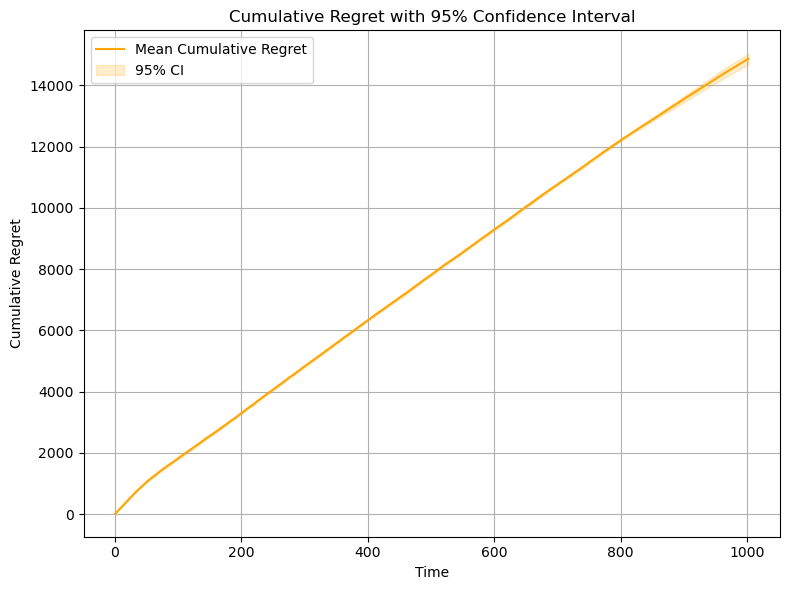

In [8]:
# Calculate the 95% confidence interval for the cumulative regret
lower_bound = cumulative_regret_mean - 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))
upper_bound = cumulative_regret_mean + 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))

# Plot the mean cumulative regret with confidence intervals
plt.figure(figsize=(8, 6))
time_steps = range(1, len(cumulative_regret_mean) + 1)

# Plot the mean line
plt.plot(time_steps, cumulative_regret_mean, label='Mean Cumulative Regret', color='orange')

# Fill the 95% confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% CI')

# Add title, labels, and legend
plt.title('Cumulative Regret with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Cumulative Regret')
plt.grid()
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [9]:
np.save('cumulative_regret_thresholded-lasso-bandit-d100-s10_10times.npy', cumulative_regret_times)
np.save('l_2_error_parameter_thresholded-lasso-bandit-d100-s10_10times.npy', l_2_error_parameter_times)